# Experiment: Recommendation Agent Evaluation

This notebook compares the recommendation pool sent to GPT against the cards GPT selected. It expects the artifacts written by `backend/recommendation_engine/evaluate_recommendations.py`.

What it shows:
- every card in each GPT candidate group
- the deterministic 0-100 evaluation score for each card
- which cards GPT picked from that pool
- whether GPT picked cards above the pool average


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 120)

REPO_ROOT_CANDIDATES = [
    Path.cwd(),
    *Path.cwd().parents,
    Path("/Users/arjunranade/CP_CSC/CSC-580/PokeHunter"),
]
REPO_ROOT = next(
    (
        candidate
        for candidate in REPO_ROOT_CANDIDATES
        if (candidate / "backend").exists() and (candidate / "output").exists()
    ),
    None,
)
if REPO_ROOT is None:
    raise FileNotFoundError("Could not locate the PokeHunter repo root from this notebook session.")

OUTPUT_ROOT = REPO_ROOT / "output" / "recommendation-evals"
if not OUTPUT_ROOT.exists():
    raise FileNotFoundError(f"Run evaluate_recommendations.py first so {OUTPUT_ROOT} exists.")

run_dirs = [path for path in OUTPUT_ROOT.iterdir() if path.is_dir()]
if not run_dirs:
    raise FileNotFoundError(f"No evaluation run directories were found under {OUTPUT_ROOT}.")

EVAL_DIR = max(run_dirs, key=lambda candidate: candidate.stat().st_mtime)
CARDS_PATH = EVAL_DIR / "cards.csv"
SUMMARY_PATH = EVAL_DIR / "summary.json"
TRACE_PATH = EVAL_DIR / "trace.json"

for artifact in (CARDS_PATH, SUMMARY_PATH, TRACE_PATH):
    if not artifact.exists():
        raise FileNotFoundError(f"Missing expected artifact: {artifact}")

{
    "repo_root": str(REPO_ROOT),
    "eval_dir": str(EVAL_DIR),
    "cards_csv": str(CARDS_PATH),
    "summary_json": str(SUMMARY_PATH),
    "trace_json": str(TRACE_PATH),
}


{'repo_root': '/Users/arjunranade/CP_CSC/CSC-580/PokeHunter',
 'eval_dir': '/Users/arjunranade/CP_CSC/CSC-580/PokeHunter/output/recommendation-evals/def5fae1-6090-44b3-97c8-48db5f709410',
 'cards_csv': '/Users/arjunranade/CP_CSC/CSC-580/PokeHunter/output/recommendation-evals/def5fae1-6090-44b3-97c8-48db5f709410/cards.csv',
 'summary_json': '/Users/arjunranade/CP_CSC/CSC-580/PokeHunter/output/recommendation-evals/def5fae1-6090-44b3-97c8-48db5f709410/summary.json',
 'trace_json': '/Users/arjunranade/CP_CSC/CSC-580/PokeHunter/output/recommendation-evals/def5fae1-6090-44b3-97c8-48db5f709410/trace.json'}

## Scoring formulas

Definitions for a card `c`:
- `P(c)`: normalized Pokemon affinity weight in `[0, 1]`
- `S(c)`: normalized set affinity weight in `[0, 1]`
- `R(c)`: normalized rarity affinity weight in `[0, 1]`

Bucket alignment:

`A_pokemon(c) = 0.50 * P(c) + 0.30 * S(c) + 0.20 * R(c)`

`A_set(c) = 0.50 * S(c) + 0.30 * P(c) + 0.20 * R(c)`

`A_rarity(c) = 0.50 * R(c) + 0.30 * S(c) + 0.20 * P(c)`

Budget fit:

- if price is missing: `B(c) = 0.50`
- if `price_usd <= budget_usd`: `B(c) = 1 - 0.5 * (price_usd / budget_usd)`
- if `price_usd > budget_usd`: `B(c) = max(0, 0.5 - 0.5 * min(1, (price_usd - budget_usd) / budget_usd))`

Final score:

`Score_100(c, g) = round(100 * (0.80 * A_g(c) + 0.20 * B(c)), 2)`

Aggregate comparison:

- `PoolMean(g) = mean score of all cards sent to GPT for group g`
- `SelectedMean(g) = mean score of GPT-selected cards for group g`
- `Lift(g) = SelectedMean(g) - PoolMean(g)`
- `Top5Capture(g) = GPT-selected cards in group top 5 / GPT-selected cards in group`


In [2]:
cards = pd.read_csv(CARDS_PATH)
summary = json.loads(SUMMARY_PATH.read_text(encoding="utf-8"))
trace = json.loads(TRACE_PATH.read_text(encoding="utf-8"))

for column in ["selected_by_gpt", "selected_in_final_response"]:
    cards[column] = cards[column].astype(str).str.lower().eq("true")

numeric_columns = [
    "price_usd",
    "score_100",
    "pokemon_weight",
    "set_weight",
    "rarity_weight",
    "alignment_score",
    "budget_score",
    "rank_in_group_pool",
]
for column in numeric_columns:
    cards[column] = pd.to_numeric(cards[column], errors="coerce")

summary_rows = []
for group_key, metrics in summary.get("per_group", {}).items():
    summary_rows.append({
        "group_key": group_key,
        "title": metrics["title"],
        "pool_count": metrics["pool_count"],
        "selected_count": metrics["selected_count"],
        "pool_mean": metrics["pool_mean"],
        "selected_mean": metrics["selected_mean"],
        "lift": metrics["lift"],
        "top_5_capture": metrics["top_5_capture"],
        "invalid_selection_count": metrics["invalid_selection_count"],
    })
summary_df = pd.DataFrame(summary_rows).sort_values("title")

print(trace["profile_summary"])
summary_df


Recommendations selected with unique card IDs across groups.


,group_key,title,pool_count,selected_count,pool_mean,selected_mean,lift,top_5_capture,invalid_selection_count
0,pokemon_affinity,Pokemon Affinity,7,5,65.43,68.40,2.97,1.0,0
2,rarity_affinity,Rarity Affinity,7,2,48.00,44.00,-4.00,0.5,0
1,set_affinity,Set Affinity,10,5,60.54,56.93,-3.60,0.2,0


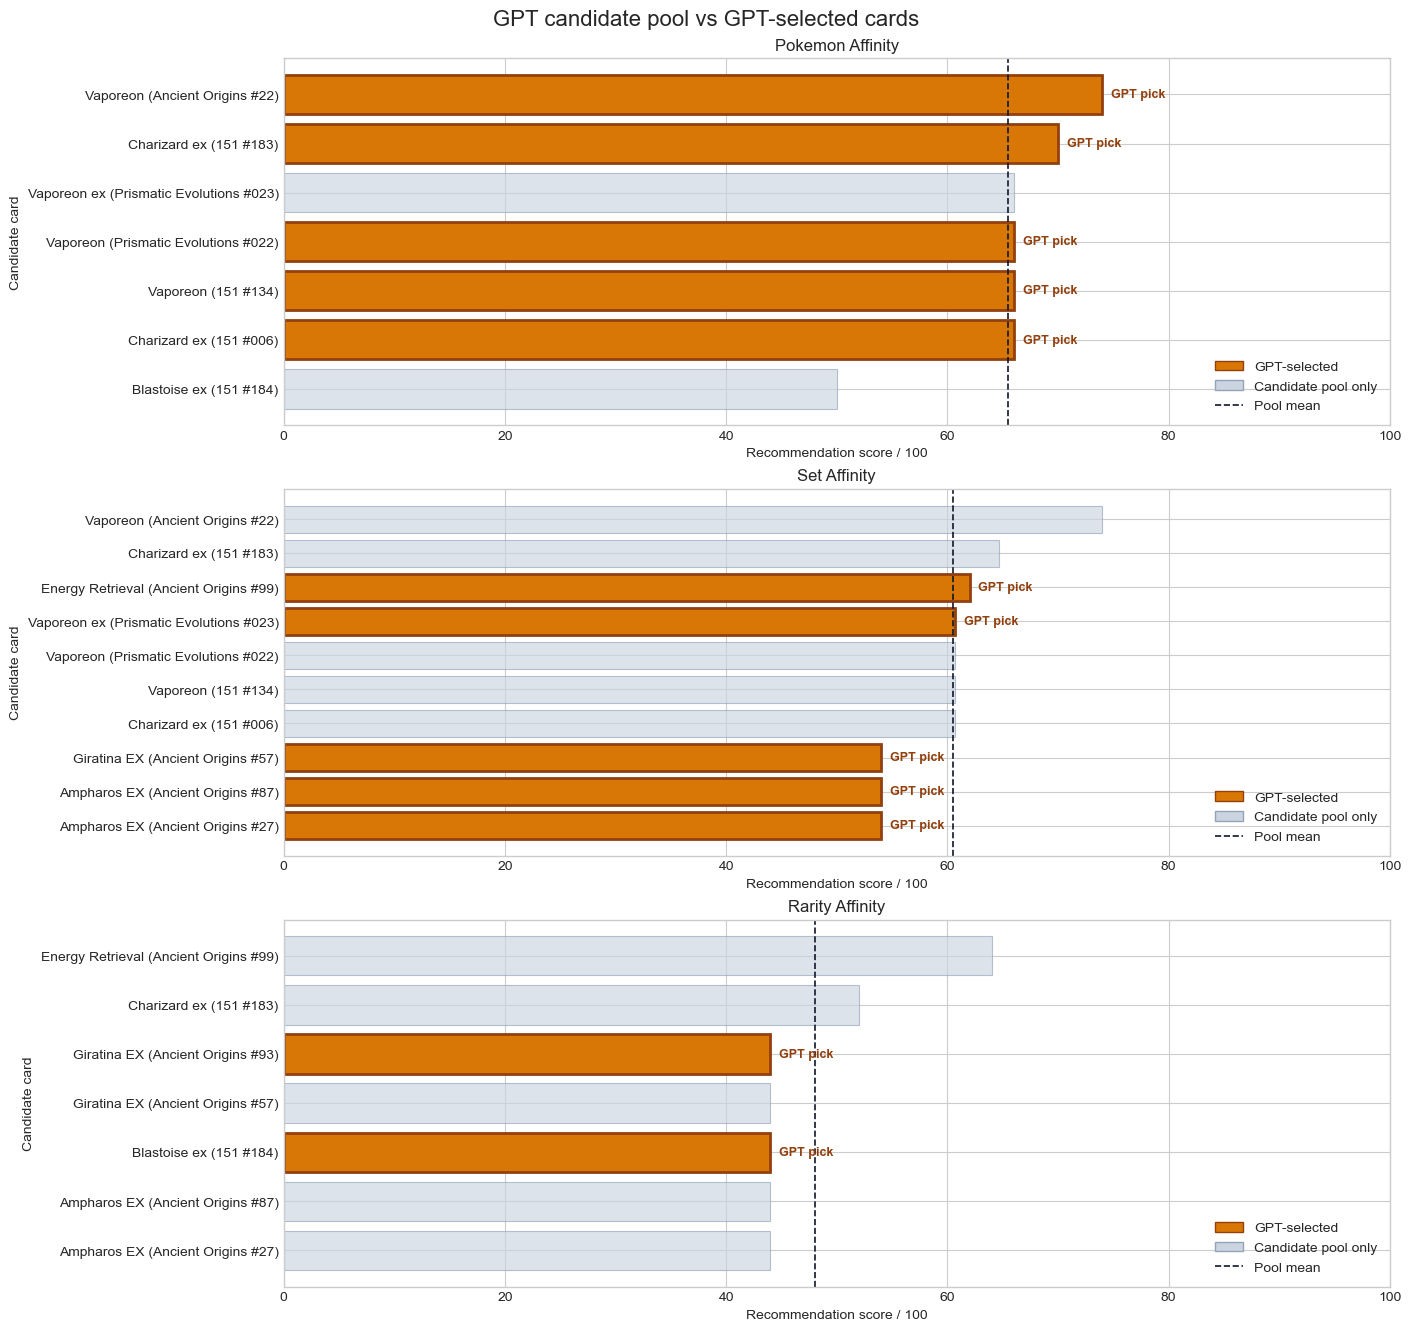

In [3]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

group_order = list(summary.get("per_group", {}).keys()) or sorted(cards["group_key"].unique())
fig, axes = plt.subplots(len(group_order), 1, figsize=(14, max(6, len(cards) * 0.55)), constrained_layout=True)
if len(group_order) == 1:
    axes = [axes]

for ax, group_key in zip(axes, group_order):
    group_cards = cards[cards["group_key"] == group_key].copy()
    if group_cards.empty:
        ax.set_visible(False)
        continue

    group_cards = group_cards.sort_values(["score_100", "card_label"], ascending=[True, True]).reset_index(drop=True)
    selected_mask = group_cards["selected_by_gpt"].to_numpy()
    colors = np.where(selected_mask, "#d97706", "#cbd5e1")
    edges = np.where(selected_mask, "#92400e", "#94a3b8")
    linewidths = np.where(selected_mask, 2.0, 0.8)
    alpha_values = np.where(selected_mask, 1.0, 0.65)

    bars = ax.barh(
        group_cards["card_label"],
        group_cards["score_100"],
        color=colors,
        edgecolor=edges,
        linewidth=linewidths,
    )

    for bar, is_selected, score, alpha_value in zip(
        bars,
        selected_mask,
        group_cards["score_100"],
        alpha_values,
    ):
        bar.set_alpha(float(alpha_value))
        if not is_selected:
            continue
        y_pos = bar.get_y() + bar.get_height() / 2
        ax.text(
            float(score) + 0.8,
            y_pos,
            "GPT pick",
            va="center",
            ha="left",
            fontsize=9,
            color="#92400e",
            fontweight="bold",
        )

    pool_mean = float(group_cards["score_100"].mean())
    ax.axvline(pool_mean, color="#0f172a", linestyle="--", linewidth=1.2)
    ax.set_title(summary.get("per_group", {}).get(group_key, {}).get("title", group_key))
    ax.set_xlabel("Recommendation score / 100")
    ax.set_ylabel("Candidate card")
    ax.set_xlim(0, max(100, float(group_cards["score_100"].max()) + 10))

    legend_handles = [
        Patch(facecolor="#d97706", edgecolor="#92400e", label="GPT-selected"),
        Patch(facecolor="#cbd5e1", edgecolor="#94a3b8", label="Candidate pool only"),
        Line2D([0], [0], color="#0f172a", linestyle="--", linewidth=1.2, label="Pool mean"),
    ]
    ax.legend(handles=legend_handles, loc="lower right")

fig.suptitle("GPT candidate pool vs GPT-selected cards", fontsize=16)
plt.show()


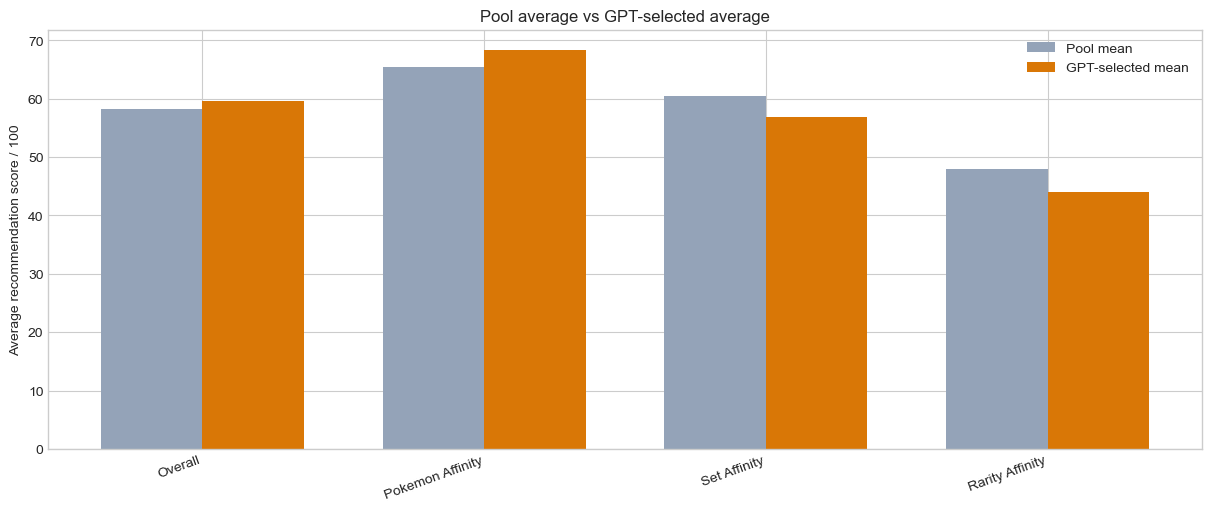

,label,pool_mean,selected_mean
0,Overall,58.31,59.56
1,Pokemon Affinity,65.43,68.40
2,Set Affinity,60.54,56.93
3,Rarity Affinity,48.00,44.00


In [4]:
comparison_rows = [
    {
        "label": "Overall",
        "pool_mean": summary.get("overall_pool_mean", 0.0),
        "selected_mean": summary.get("overall_selected_mean", 0.0),
    }
]
for group_key, metrics in summary.get("per_group", {}).items():
    comparison_rows.append({
        "label": metrics["title"],
        "pool_mean": metrics["pool_mean"],
        "selected_mean": metrics["selected_mean"],
    })
comparison_df = pd.DataFrame(comparison_rows)

x = np.arange(len(comparison_df))
width = 0.36
fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)
ax.bar(x - width / 2, comparison_df["pool_mean"], width=width, label="Pool mean", color="#94a3b8")
ax.bar(x + width / 2, comparison_df["selected_mean"], width=width, label="GPT-selected mean", color="#d97706")
ax.set_xticks(x)
ax.set_xticklabels(comparison_df["label"], rotation=20, ha="right")
ax.set_ylabel("Average recommendation score / 100")
ax.set_title("Pool average vs GPT-selected average")
ax.legend()
plt.show()

comparison_df


In [5]:
conclusion_rows = []
for group_key, metrics in summary.get("per_group", {}).items():
    conclusion_rows.append({
        "group": metrics["title"],
        "pool_mean": metrics["pool_mean"],
        "selected_mean": metrics["selected_mean"],
        "lift": metrics["lift"],
        "top_5_capture": metrics["top_5_capture"],
        "invalid_selection_count": metrics["invalid_selection_count"],
    })

pd.DataFrame(conclusion_rows).sort_values("group")


,group,pool_mean,selected_mean,lift,top_5_capture,invalid_selection_count
0,Pokemon Affinity,65.43,68.40,2.97,1.0,0
2,Rarity Affinity,48.00,44.00,-4.00,0.5,0
1,Set Affinity,60.54,56.93,-3.60,0.2,0


## How to read the charts

- Orange bars are the cards GPT selected from the candidate pool.
- Light gray bars are cards that were available to GPT but were not selected.
- The `GPT pick` label is added next to every selected card for quick scanning.
- The dashed line is the average score of the full candidate pool for that group.
- If the orange bars sit to the right of the dashed line, GPT is selecting above-average cards by this metric.
